# Day 061 — Principal Component Analysis (PCA)


In [8]:
# Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


## 1. PCA — Linear Dimensionality Reduction & Standardization


In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

# Standardize
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
print(f"Dataset Shape: {X_std.shape}")

Dataset Shape: (150, 4)


## 2. Covariance Matrix Computation


In [3]:
cov_mat = np.cov(X_std.T)
print("Covariance Matrix (4x4):")
print(np.round(cov_mat, 3))

Covariance Matrix (4x4):
[[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]


## 3. Eigenvalues & Eigenvectors Derivation


In [4]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

# Sort eigenvectors by descending eigenvalues
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

print("Eigenvalues:")
print(eig_vals)

Eigenvalues:
[2.93808505 0.9201649  0.14774182 0.02085386]


## 4. Explained Variance Ratio & Scree Plot


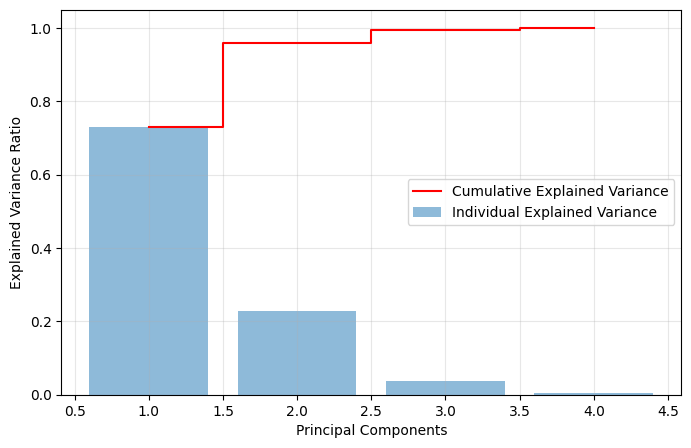

In [5]:
tot = sum(eig_vals)
var_exp = [(i / tot) for i in eig_vals]
cum_var_exp = np.cumsum(var_exp)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 5), var_exp, alpha=0.5, align='center', label='Individual Explained Variance')
plt.step(range(1, 5), cum_var_exp, where='mid', label='Cumulative Explained Variance', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Dimensionality Reduction & Feature Projection


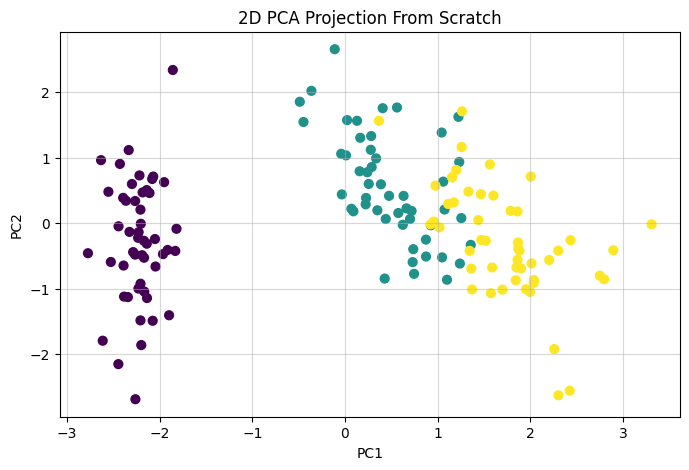

In [6]:
# Project onto top 2 components
W = eig_vecs[:, :2]
X_pca_custom = X_std.dot(W)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca_custom[:, 0], X_pca_custom[:, 1], c=y, cmap='viridis', s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection From Scratch')
plt.grid(True, alpha=0.5)
plt.show()

## 6. PCA From Scratch (NumPy) vs Scikit-Learn Validation


In [7]:
from sklearn.decomposition import PCA

pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_std)

print("Scikit-Learn Explained Variance Ratio:", pca_sklearn.explained_variance_ratio_)
print("Custom NumPy Explained Variance Ratio:", np.round(var_exp[:2], 4))

Scikit-Learn Explained Variance Ratio: [0.72962445 0.22850762]
Custom NumPy Explained Variance Ratio: [0.7296 0.2285]
